# Data Pipeline for ML

In [ ]:
%%time
import warnings
warnings.filterwarnings("ignore")

%python3 -m pip install --upgrade pip

CPU times: user 15 μs, sys: 1 μs, total: 16 μs
Wall time: 16.2 μs


In [ ]:
%%time
# pandas==2.2.2 numpy==1.26.4 scikit-learn==1.4.2 matplotlib==3.8.4
%pip install -U pandas numpy matplotlib scikit-learn ipython-autotime ipywidgets

%load_ext autotime

Note: you may need to restart the kernel to use updated packages.
CPU times: user 12.9 ms, sys: 12.6 ms, total: 25.5 ms
Wall time: 1.55 s
time: 396 μs (started: 2025-04-28 20:02:59 -07:00)


In [3]:
# # pandas==2.2.2 numpy==1.26.4 scikit-learn==1.4.2 matplotlib==3.8.4
import pandas as pd
print(f" pandas: {pd.__version__}")
import numpy as np
print(f" numpy: {np.__version__}")
import matplotlib as mpt
print(f" matplotlib: {mpt.__version__}")
import sklearn
print(f" sklearn: {sklearn.__version__}") 
print(f" sklearn: {sklearn.show_versions()}")

 pandas: 2.2.3
 numpy: 2.2.5
 matplotlib: 3.10.1
 sklearn: 1.6.1

System:
    python: 3.11.12 (main, Apr  8 2025, 14:15:29) [Clang 16.0.0 (clang-1600.0.26.6)]
executable: /opt/homebrew/opt/python@3.11/bin/python3.11
   machine: macOS-15.3.2-arm64-arm-64bit

Python dependencies:
      sklearn: 1.6.1
          pip: 25.0.1
   setuptools: 78.1.0
        numpy: 2.2.5
        scipy: 1.14.1
       Cython: None
       pandas: 2.2.3
   matplotlib: 3.10.1
       joblib: 1.4.2
threadpoolctl: 3.5.0

Built with OpenMP: True

threadpoolctl info:
       user_api: openmp
   internal_api: openmp
    num_threads: 11
         prefix: libomp
       filepath: /opt/homebrew/lib/python3.11/site-packages/sklearn/.dylibs/libomp.dylib
        version: None
 sklearn: None
time: 2.67 s (started: 2025-04-28 20:02:59 -07:00)



✅ Model Trained!
📈 Mean Squared Error on Test Set: 62.20

💬 Predicted Stock Price on Day 101: $149.42


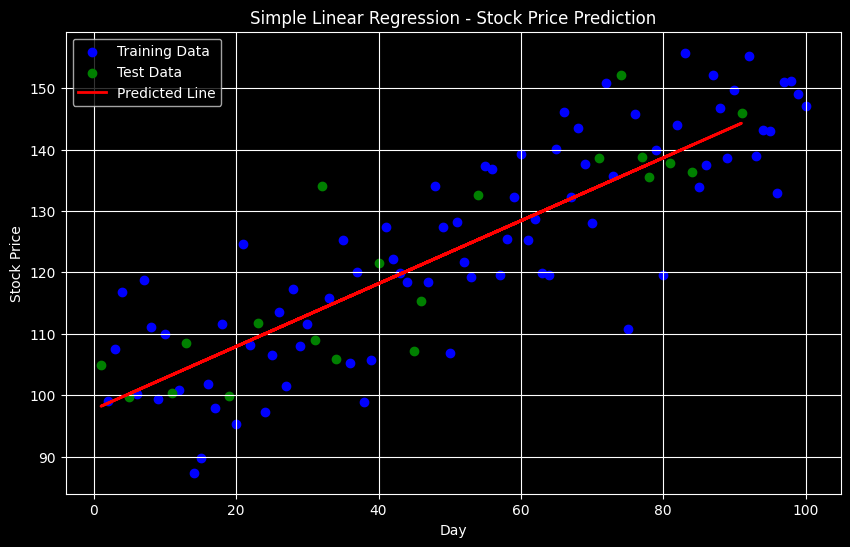

time: 2.86 s (started: 2025-04-28 20:03:01 -07:00)


In [4]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

# Step 1: Simulate Raw Data
np.random.seed(42)
data = {
    "Day": np.arange(1, 101),
    "Stock_Price": np.random.normal(100, 10, 100) + np.arange(0, 100) * 0.5
}
df = pd.DataFrame(data)

# Display raw data sample
df.head()

# Step 2: Define a simple cleaning function
def clean_data(df):
    df = df.copy()
    df['Stock_Price'] = df['Stock_Price'].clip(lower=0)  # No negative stock prices
    return df

# Step 3: Create a full pipeline
pipeline = Pipeline([
    ("scaler", StandardScaler()),  # Feature scaling
    ("model", LinearRegression())  # Linear Regression model
])

# Step 4: Apply cleaning
df_clean = clean_data(df)

# Step 5: Train/Test Split
X = df_clean[["Day"]]
y = df_clean["Stock_Price"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 6: Train the model
pipeline.fit(X_train, y_train)

# Step 7: Predict and Monitor

# Predict
y_pred = pipeline.predict(X_test)

# Evaluate performance
mse = mean_squared_error(y_test, y_pred)
print(f"\n✅ Model Trained!")
print(f"📈 Mean Squared Error on Test Set: {mse:.2f}")

# Step 8: Predict future stock price
new_day = pd.DataFrame({"Day": [101]})
predicted_price = pipeline.predict(new_day)
print(f"\n💬 Predicted Stock Price on Day 101: ${predicted_price[0]:.2f}")

# Step 9: Visualization
plt.figure(figsize=(10,6))
plt.scatter(X_train, y_train, color='blue', label='Training Data')
plt.scatter(X_test, y_test, color='green', label='Test Data')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Predicted Line')
plt.xlabel('Day')
plt.ylabel('Stock Price')
plt.title('Simple Linear Regression - Stock Price Prediction')
plt.legend()
plt.grid(True)
plt.show()
